###TIME SERIES MODELLING CASE STUDY

In [ ]:
# Part 1 - Data preparation, exploratory analysis and stationarity checks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from pathlib import Path

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")

In [ ]:
# Project folder setup
project_folder = Path("/content")
data_file = project_folder / "time_series_60min_singleindex_filtered.csv"

print("Data file:", data_file)

Data file: /content/time_series_60min_singleindex_filtered.csv


In [ ]:
# Read the dataset

power_table = pd.read_csv(data_file)

print("Dataset shape:", power_table.shape)
power_table.head()

Dataset shape: (50401, 16)


,utc_timestamp,cet_cest_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,37248.0,NaN,NaN,27913.0,NaN,NaN,667.0,NaN,NaN,27246.0,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,41151.0,39723.0,37248.0,NaN,NaN,27913.0,8852.0,0.3171,667.0,517.0,0.7744,27246.0,8336.0,0.3059
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,40135.0,38813.0,37248.0,NaN,NaN,27913.0,9054.0,0.3244,667.0,514.0,0.7710,27246.0,8540.0,0.3134
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,39106.0,38490.0,37248.0,NaN,NaN,27913.0,9070.0,0.3249,667.0,518.0,0.7761,27246.0,8552.0,0.3139
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,38765.0,38644.0,37248.0,NaN,NaN,27913.0,9163.0,0.3283,667.0,520.0,0.7793,27246.0,8643.0,0.3172


In [ ]:
# Keep only the timestamp and German actual load column

load_data = power_table[
    [
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ]
].copy()

load_data.columns = [
    "timestamp",
    "load"
]

load_data.head()

,timestamp,load
0,2014-12-31T23:00:00Z,NaN
1,2015-01-01T00:00:00Z,41151.0
2,2015-01-01T01:00:00Z,40135.0
3,2015-01-01T02:00:00Z,39106.0
4,2015-01-01T03:00:00Z,38765.0


In [ ]:
# Convert timestamp to datetime and set it as index

load_data["timestamp"] = pd.to_datetime(load_data["timestamp"])

load_data = (
    load_data
    .set_index("timestamp")
    .sort_index()
)

print("Start date:", load_data.index.min())
print("End date:", load_data.index.max())

Start date: 2014-12-31 23:00:00+00:00
End date: 2020-09-30 23:00:00+00:00


In [ ]:
# Keep the assignment period only

load_data = load_data.loc["2015-01-01":"2020-09-30"]

print(load_data.head())
print(load_data.tail())
print("Rows after filtering:", len(load_data))

                              load
timestamp                         
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                              load
timestamp                         
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0
Rows after filtering: 50400


In [ ]:
# Check missing values

missing_check = load_data.isna().sum()

print("Missing values:")
print(missing_check)

Missing values:
load    0
dtype: int64


In [ ]:
# Filling missing values

load_data["load"] = load_data["load"].interpolate()

print("Missing values after cleaning:")
print(load_data.isna().sum())

Missing values after cleaning:
load    0
dtype: int64


In [ ]:
# Create daily and weekly average series

daily_load = load_data["load"].resample("D").mean()
weekly_load = load_data["load"].resample("W").mean()

print("Hourly observations:", len(load_data))
print("Daily observations:", len(daily_load))
print("Weekly observations:", len(weekly_load))

Hourly observations: 50400
Daily observations: 2100
Weekly observations: 301


Part 2. EXPLORATORY DATA ANALYSIS

2.1 Daily demand with rolling median

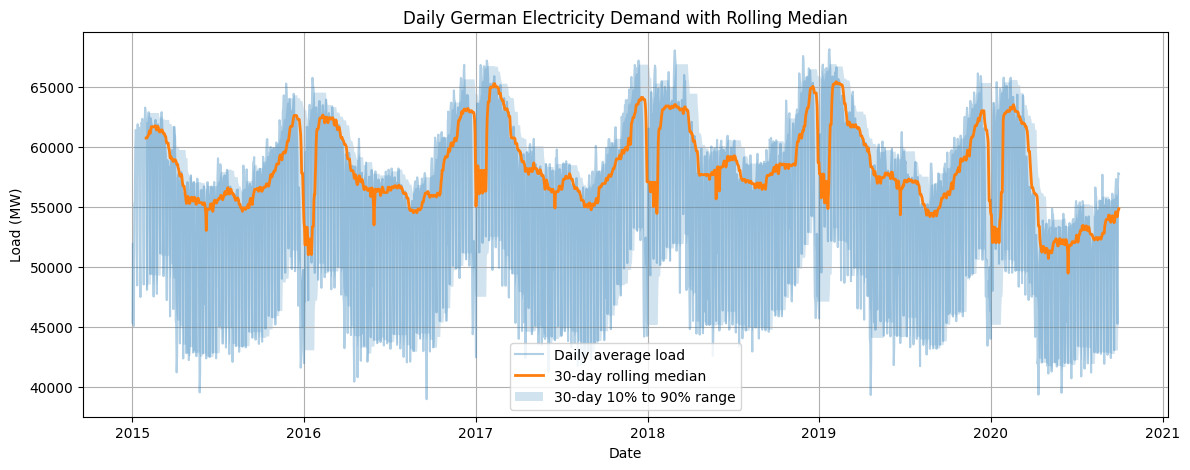

In [ ]:
# Daily demand with rolling median and variation band

rolling_median = daily_load.rolling(window=30).median()
lower_band = daily_load.rolling(window=30).quantile(0.10)
upper_band = daily_load.rolling(window=30).quantile(0.90)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_load.index,
    daily_load,
    alpha=0.35,
    label="Daily average load"
)

plt.plot(
    rolling_median.index,
    rolling_median,
    linewidth=2,
    label="30-day rolling median"
)

plt.fill_between(
    daily_load.index,
    lower_band,
    upper_band,
    alpha=0.2,
    label="30-day 10% to 90% range"
)

plt.title("Daily German Electricity Demand with Rolling Median")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

2.2. Load duration curve:
This is a strong different EDA idea. It shows how often high and low demand levels occur.

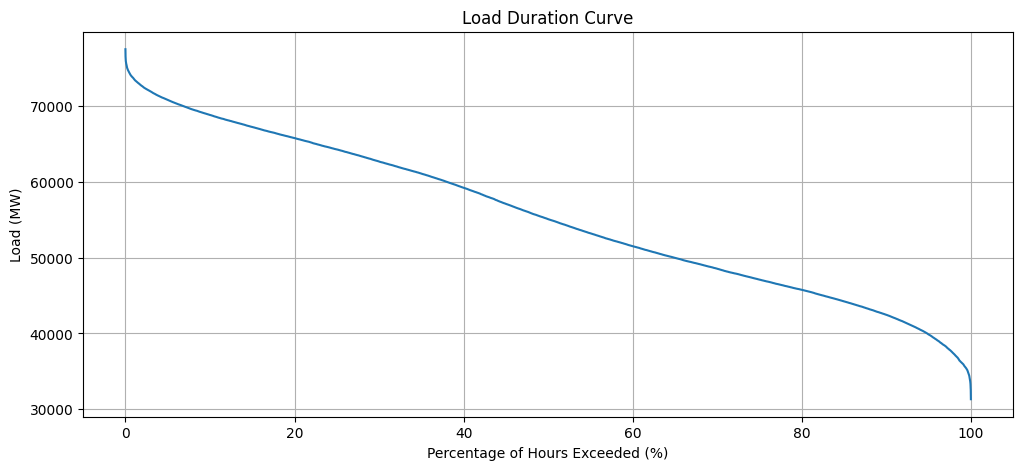

In [ ]:
sorted_load = np.sort(load_data["load"].dropna().values)[::-1]

hours_exceeded = np.arange(1, len(sorted_load) + 1)
exceedance_rate = hours_exceeded / len(sorted_load) * 100

plt.figure(figsize=(12, 5))

plt.plot(
    exceedance_rate,
    sorted_load
)

plt.title("Load Duration Curve")
plt.xlabel("Percentage of Hours Exceeded (%)")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

2.3. Monthly seasonal index:
This is different from a normal monthly average plot. It shows how each month compares with the overall average.

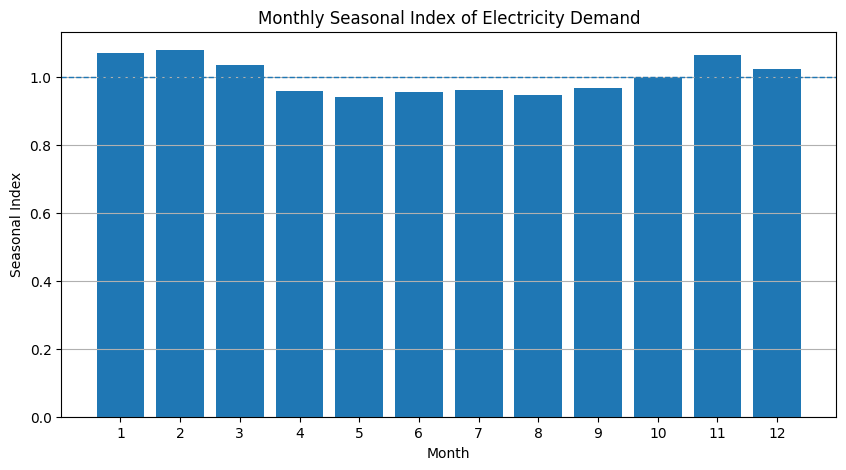

In [ ]:
# Monthly seasonal index
# A value above 1 means demand is above the overall average

monthly_average = load_data["load"].resample("M").mean().to_frame(name="load")

monthly_average["month"] = monthly_average.index.month

overall_average = monthly_average["load"].mean()

seasonal_index = (
    monthly_average
    .groupby("month")["load"]
    .mean()
    / overall_average
)

plt.figure(figsize=(10, 5))

plt.bar(
    seasonal_index.index,
    seasonal_index.values
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.title("Monthly Seasonal Index of Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Seasonal Index")
plt.xticks(range(1, 13))
plt.grid(axis="y")
plt.show()

2.4. Weekday and weekend hourly profile

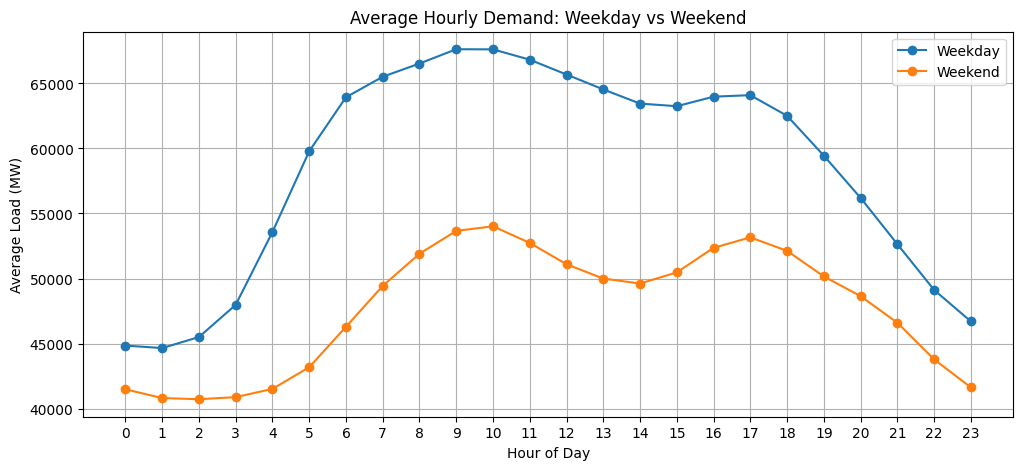

In [ ]:
# Compare average hourly demand on weekdays and weekends

hourly_pattern = load_data.copy()

hourly_pattern["hour"] = hourly_pattern.index.hour
hourly_pattern["day_type"] = np.where(
    hourly_pattern.index.dayofweek < 5,
    "Weekday",
    "Weekend"
)

hourly_profile = (
    hourly_pattern
    .groupby(["hour", "day_type"])["load"]
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile["Weekday"],
    marker="o",
    label="Weekday"
)

plt.plot(
    hourly_profile.index,
    hourly_profile["Weekend"],
    marker="o",
    label="Weekend"
)

plt.title("Average Hourly Demand: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.show()

2.5. Rolling **volatility**

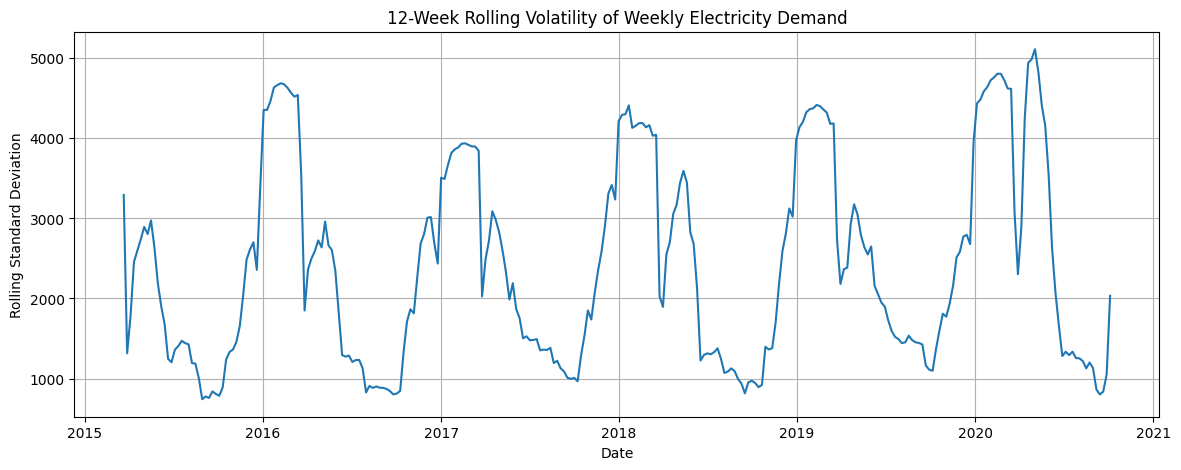

In [ ]:
# Rolling volatility of weekly demand

weekly_volatility = weekly_load.rolling(window=12).std()

plt.figure(figsize=(14, 5))

plt.plot(
    weekly_volatility.index,
    weekly_volatility
)

plt.title("12-Week Rolling Volatility of Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(True)
plt.show()

# 2.6. Seasonal decomposition

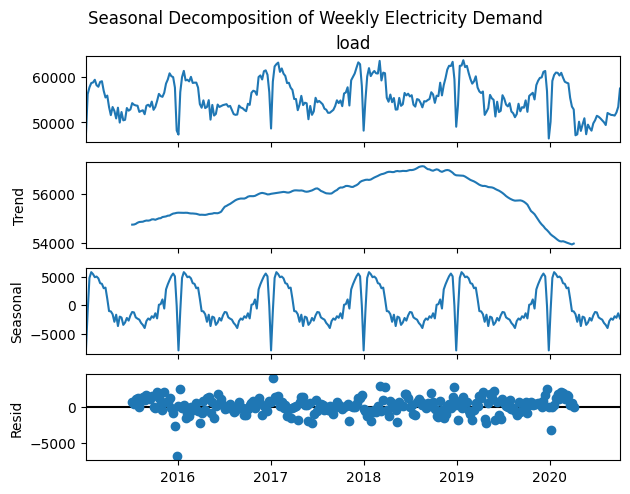

In [ ]:
# Seasonal decomposition using 52 weeks as yearly seasonality

decomposition = seasonal_decompose(
    weekly_load.dropna(),
    model="additive",
    period=52
)

decomposition.plot()
plt.suptitle("Seasonal Decomposition of Weekly Electricity Demand", y=1.02)
plt.show()

## 2.7. Stationarity Tests

In [ ]:
# Function for ADF and KPSS stationarity tests

def check_stationarity(series, label):

    clean_series = series.dropna()

    adf_result = adfuller(clean_series)
    kpss_result = kpss(
        clean_series,
        regression="c",
        nlags="auto"
    )

    output = {
        "Series": label,
        "ADF Statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS Statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1],
        "ADF Conclusion": "Stationary" if adf_result[1] < 0.05 else "Non-stationary",
        "KPSS Conclusion": "Stationary" if kpss_result[1] > 0.05 else "Non-stationary"
    }

    return output

In [ ]:
# First differenced weekly series

weekly_difference = weekly_load.diff()

In [ ]:
# Stationarity summary table

stationarity_table = pd.DataFrame(
    [
        check_stationarity(
            weekly_load,
            "Weekly load"
        ),
        check_stationarity(
            weekly_difference,
            "First differenced weekly load"
        )
    ]
)

stationarity_table

,Series,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value,ADF Conclusion,KPSS Conclusion
0,Weekly load,-4.047472,1.181350e-03,0.160374,0.1,Stationary,Stationary
1,First differenced weekly load,-7.069318,4.984737e-10,0.055754,0.1,Stationary,Stationary


3. ACF and PACF plots

<Figure size 1200x400 with 0 Axes>

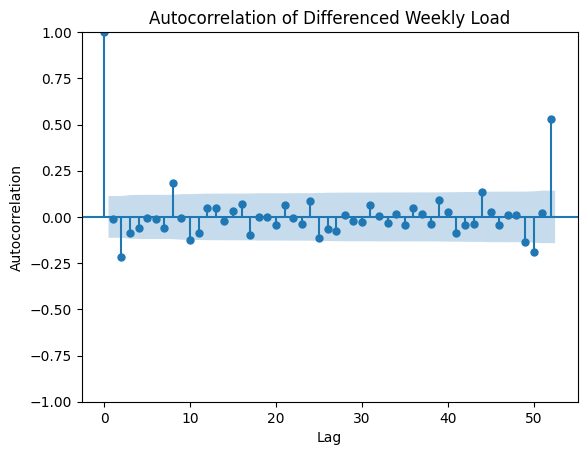

In [ ]:
# I focus on the differenced series because the stationarity test already checked the original weekly load

plt.figure(figsize=(12, 4))

plot_acf(
    weekly_difference.dropna(),
    lags=52
)

plt.title("Autocorrelation of Differenced Weekly Load")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

<Figure size 1200x400 with 0 Axes>

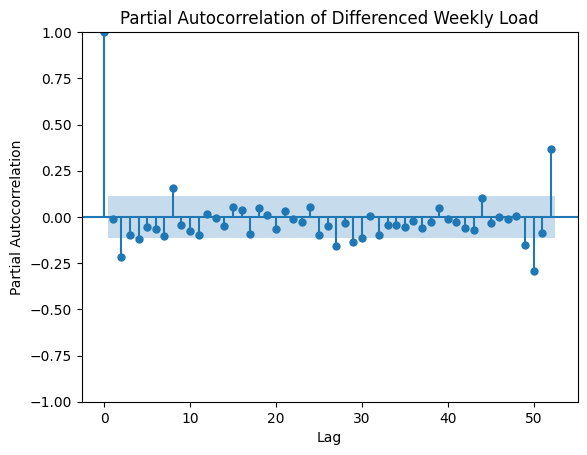

In [ ]:
plt.figure(figsize=(12, 4))

plot_pacf(
    weekly_difference.dropna(),
    lags=52,
    method="ywm"
)

plt.title("Partial Autocorrelation of Differenced Weekly Load")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

In [ ]:
#numerical summary
from statsmodels.tsa.stattools import acf

acf_values = acf(
    weekly_difference.dropna(),
    nlags=52
)

acf_summary = pd.DataFrame({
    "Lag": np.arange(len(acf_values)),
    "ACF Value": acf_values
})

acf_summary["Absolute ACF"] = acf_summary["ACF Value"].abs()

top_acf_lags = (
    acf_summary
    .query("Lag > 0")
    .sort_values("Absolute ACF", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_acf_lags

,Lag,ACF Value,Absolute ACF
0,52,0.528760,0.528760
1,2,-0.214385,0.214385
2,50,-0.192166,0.192166
3,8,0.183157,0.183157
4,44,0.136044,0.136044
5,49,-0.134737,0.134737
6,10,-0.124726,0.124726
7,25,-0.114918,0.114918
8,17,-0.096475,0.096475
9,39,0.093839,0.093839


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def forecast_error(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    return rmse, mae, mape

In [ ]:
weekly_series = weekly_load.copy()

In [ ]:
# Train-test split
# Last 104 weeks are kept for testing, which is around two years

test_weeks = 104

load_train = weekly_series.iloc[:-test_weeks]
load_test = weekly_series.iloc[-test_weeks:]

print("Training data:", load_train.index.min(), "to", load_train.index.max())
print("Testing data:", load_test.index.min(), "to", load_test.index.max())
print("Train size:", len(load_train))
print("Test size:", len(load_test))

Training data: 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Testing data: 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Train size: 197
Test size: 104


In [ ]:
# Mean forecast
# Forecasts all future weeks using the average training load

mean_forecast = pd.Series(
    np.repeat(load_train.mean(), len(load_test)),
    index=load_test.index,
    name="Mean Forecast"
)

In [ ]:
# Naive forecast
# Uses the last observed training value for every future week

naive_forecast = pd.Series(
    np.repeat(load_train.iloc[-1], len(load_test)),
    index=load_test.index,
    name="Naive Forecast"
)

In [ ]:
# Seasonal naive forecast
# Weekly data has yearly seasonality, so 52 weeks are used as the seasonal cycle

season_length = 52

last_season = load_train.iloc[-season_length:].values

seasonal_values = np.resize(
    last_season,
    len(load_test)
)

seasonal_naive_forecast = pd.Series(
    seasonal_values,
    index=load_test.index,
    name="Seasonal Naive Forecast"
)

In [ ]:
# Drift forecast
# Extends the average historical change from the first training value to the last one

start_value = load_train.iloc[0]
end_value = load_train.iloc[-1]

average_change = (end_value - start_value) / (len(load_train) - 1)

drift_values = [
    end_value + average_change * step
    for step in range(1, len(load_test) + 1)
]

drift_forecast = pd.Series(
    drift_values,
    index=load_test.index,
    name="Drift Forecast"
)

In [ ]:
# Put all benchmark forecasts together

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

In [ ]:
# Evaluate all benchmark models

benchmark_rows = []

for model_name, forecast_values in benchmark_forecasts.items():

    rmse, mae, mape = forecast_error(
        load_test,
        forecast_values
    )

    benchmark_rows.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

benchmark_table

,Model,RMSE,MAE,MAPE
0,Seasonal Naive,3006.760812,2318.520585,4.408920
1,Mean,4397.299694,3788.833122,6.969238
2,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
seasonal_naive_forecast = benchmark_forecasts["Seasonal Naive"]

seasonal_naive_row = benchmark_table[
    benchmark_table["Model"] == "Seasonal Naive"
].iloc[0]

seasonal_naive_rmse = seasonal_naive_row["RMSE"]
seasonal_naive_mae = seasonal_naive_row["MAE"]
seasonal_naive_mape = seasonal_naive_row["MAPE"]

print("Seasonal Naive Results")
print("RMSE:", seasonal_naive_rmse)
print("MAE:", seasonal_naive_mae)
print("MAPE:", seasonal_naive_mape)

Seasonal Naive Results
RMSE: 3006.7608119599954
MAE: 2318.5205853174602
MAPE: 4.408919739301198


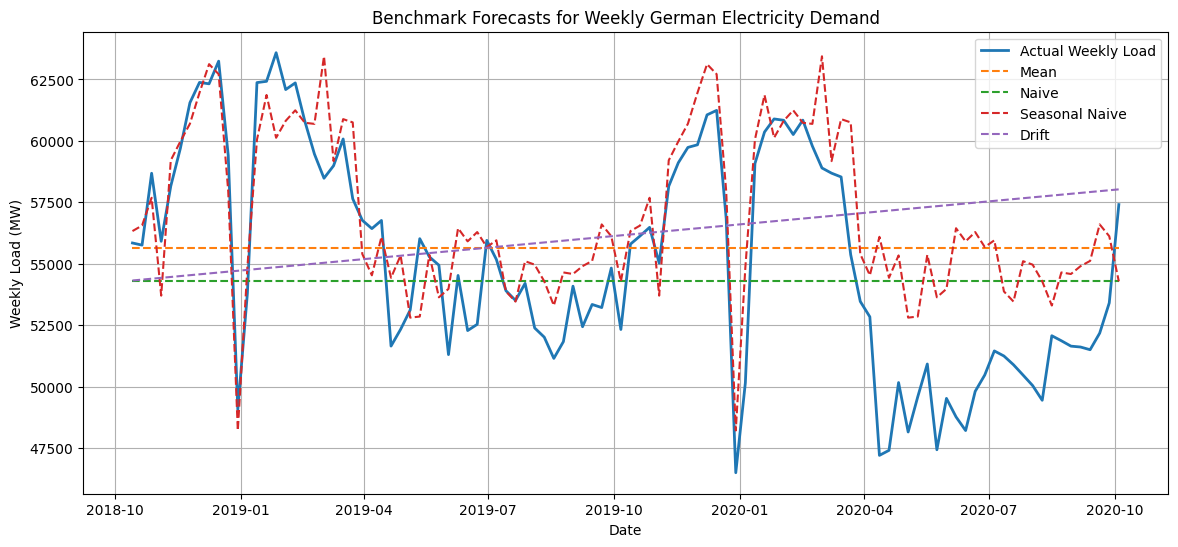

In [ ]:
# Plot benchmark forecasts against actual test data

plt.figure(figsize=(14, 6))

plt.plot(
    load_test.index,
    load_test,
    label="Actual Weekly Load",
    linewidth=2
)

for model_name, forecast_values in benchmark_forecasts.items():
    plt.plot(
        forecast_values.index,
        forecast_values,
        linestyle="--",
        label=model_name
    )

plt.title("Benchmark Forecasts for Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Weekly Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

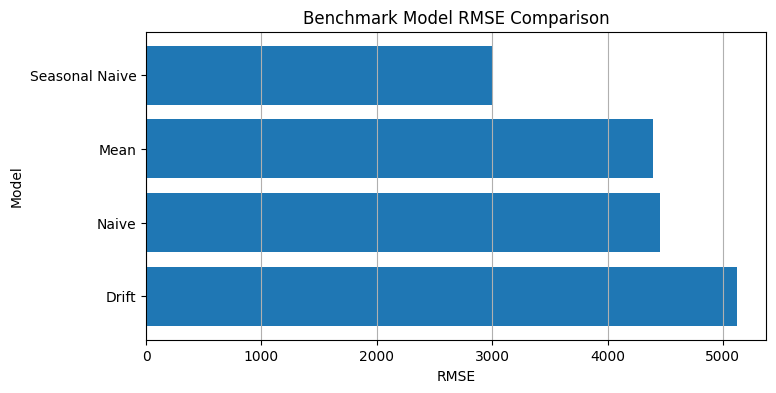

In [ ]:
# Simple RMSE ranking plot for benchmark models

benchmark_plot = benchmark_table.sort_values("RMSE", ascending=True)

plt.figure(figsize=(8, 4))

plt.barh(
    benchmark_plot["Model"],
    benchmark_plot["RMSE"]
)

plt.title("Benchmark Model RMSE Comparison")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [ ]:
# Store benchmark result for later use

benchmark_result = pd.DataFrame({
    "Model": ["Seasonal Naive"],
    "RMSE": [seasonal_naive_rmse],
    "MAE": [seasonal_naive_mae],
    "MAPE": [seasonal_naive_mape]
})

benchmark_result

,Model,RMSE,MAE,MAPE
0,Seasonal Naive,3006.760812,2318.520585,4.40892


# Part 3: **SARIMA** **Model**

In [ ]:
import itertools

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
# Last 104 weeks are used as the test period

test_weeks = 104

load_train = weekly_series.iloc[:-test_weeks]
load_test = weekly_series.iloc[-test_weeks:]

print("Training period:", load_train.index.min(), "to", load_train.index.max())
print("Testing period:", load_test.index.min(), "to", load_test.index.max())

print("Training observations:", len(load_train))
print("Testing observations:", len(load_test))

Training period: 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Testing period: 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Training observations: 197
Testing observations: 104


In [ ]:
# SARIMA parameter search
# The assignment requires p = 0-6, d = 0-2, q = 0-6

p_range = range(0, 7)
d_range = range(0, 3)
q_range = range(0, 7)

sarima_orders = list(
    itertools.product(
        p_range,
        d_range,
        q_range
    )
)

seasonal_part = (1, 1, 1, 52)

print("Total SARIMA models to try:", len(sarima_orders))

Total SARIMA models to try: 147


In [ ]:
# Function to fit one SARIMA model and return AIC

def try_sarima_model(order_value):

    try:
        model = SARIMAX(
            load_train,
            order=order_value,
            seasonal_order=seasonal_part,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        return {
            "Order": order_value,
            "Seasonal Order": seasonal_part,
            "AIC": fitted.aic,
            "Status": "Success"
        }

    except:
        return {
            "Order": order_value,
            "Seasonal Order": seasonal_part,
            "AIC": np.nan,
            "Status": "Failed"
        }

In [ ]:
# Running the grid search

search_output = []

for order_value in sarima_orders:

    result = try_sarima_model(order_value)
    search_output.append(result)

    if result["Status"] == "Success":
        print("Done:", order_value, "AIC:", round(result["AIC"], 2))
    else:
        print("Failed:", order_value)

Done: (0, 0, 0) AIC: 1635.34
Done: (0, 0, 1) AIC: 1603.93
Done: (0, 0, 2) AIC: 1585.54
Done: (0, 0, 3) AIC: 1560.74
Done: (0, 0, 4) AIC: 1541.19
Done: (0, 0, 5) AIC: 1527.51
Done: (0, 0, 6) AIC: 1508.72
Done: (0, 1, 0) AIC: 1617.86
Done: (0, 1, 1) AIC: 1582.12
Done: (0, 1, 2) AIC: 1564.7
Done: (0, 1, 3) AIC: 1546.17
Done: (0, 1, 4) AIC: 1527.85
Done: (0, 1, 5) AIC: 1509.06
Done: (0, 1, 6) AIC: 1490.46
Done: (0, 2, 0) AIC: 1697.13
Done: (0, 2, 1) AIC: 1604.33
Done: (0, 2, 2) AIC: 1567.79
Done: (0, 2, 3) AIC: 1546.12
Done: (0, 2, 4) AIC: 1521.07
Done: (0, 2, 5) AIC: 1503.3
Done: (0, 2, 6) AIC: 1485.82
Done: (1, 0, 0) AIC: 1614.01
Done: (1, 0, 1) AIC: 1594.24
Done: (1, 0, 2) AIC: 1576.89
Done: (1, 0, 3) AIC: 1562.18
Done: (1, 0, 4) AIC: 1546.58
Done: (1, 0, 5) AIC: 1529.69
Done: (1, 0, 6) AIC: 1511.48
Done: (1, 1, 0) AIC: 1606.41
Done: (1, 1, 1) AIC: 1579.99
Done: (1, 1, 2) AIC: 1564.26
Done: (1, 1, 3) AIC: 1546.79
Done: (1, 1, 4) AIC: 1529.23
Done: (1, 1, 5) AIC: 1509.09
Done: (1, 1, 6) 

In [ ]:
# Convert results into a table

sarima_search_table = pd.DataFrame(search_output)

sarima_search_table = (
    sarima_search_table
    .dropna(subset=["AIC"])
    .sort_values("AIC")
    .reset_index(drop=True)
)

sarima_search_table.head(10)

,Order,Seasonal Order,AIC,Status
0,"(2, 2, 6)","(1, 1, 1, 52)",1482.273745,Success
1,"(1, 2, 6)","(1, 1, 1, 52)",1482.984883,Success
2,"(3, 2, 6)","(1, 1, 1, 52)",1483.610488,Success
3,"(4, 2, 6)","(1, 1, 1, 52)",1485.256042,Success
4,"(0, 2, 6)","(1, 1, 1, 52)",1485.816904,Success
5,"(5, 2, 6)","(1, 1, 1, 52)",1486.686705,Success
6,"(6, 2, 6)","(1, 1, 1, 52)",1488.235692,Success
7,"(0, 1, 6)","(1, 1, 1, 52)",1490.461384,Success
8,"(1, 1, 6)","(1, 1, 1, 52)",1491.630999,Success
9,"(2, 1, 6)","(1, 1, 1, 52)",1493.576695,Success


In [ ]:
#I will Keeping the top few AIC models for checking on the test set

top_sarima_orders = sarima_search_table.head(5)["Order"].tolist()

top_sarima_orders

[(2, 2, 6), (1, 2, 6), (3, 2, 6), (4, 2, 6), (0, 2, 6)]

In [ ]:
# Function to fit and evaluate shortlisted models

def evaluate_sarima_order(order_value):

    model = SARIMAX(
        load_train,
        order=order_value,
        seasonal_order=seasonal_part,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast_values = fitted.forecast(
        steps=len(load_test)
    )

    forecast_values.index = load_test.index

    rmse, mae, mape = forecast_error(
        load_test,
        forecast_values
    )

    return {
        "Order": order_value,
        "AIC": fitted.aic,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [ ]:
# Evaluate top AIC models on the test period

shortlist_results = []

for order_value in top_sarima_orders:

    try:
        result = evaluate_sarima_order(order_value)
        shortlist_results.append(result)
        print("Checked:", order_value)

    except:
        print("Could not evaluate:", order_value)

Checked: (2, 2, 6)
Checked: (1, 2, 6)
Checked: (3, 2, 6)
Checked: (4, 2, 6)
Checked: (0, 2, 6)


In [ ]:
sarima_shortlist_table = pd.DataFrame(shortlist_results)

sarima_shortlist_table = (
    sarima_shortlist_table
    .sort_values("RMSE")
    .reset_index(drop=True)
)

sarima_shortlist_table

,Order,AIC,RMSE,MAE,MAPE
0,"(4, 2, 6)",1485.256042,4765.231187,3883.622832,7.365725
1,"(3, 2, 6)",1483.610488,4804.406494,3915.467372,7.425901
2,"(1, 2, 6)",1482.984883,9445.434823,8067.949069,15.174358
3,"(2, 2, 6)",1482.273745,9470.263044,8108.347597,15.243801
4,"(0, 2, 6)",1485.816904,9589.850886,8180.497823,15.388052


In [ ]:
#Let us Select the final SARIMA order based on forecast accuracy from the shortlist

final_sarima_order = sarima_shortlist_table.loc[0, "Order"]

print("Selected SARIMA order:", final_sarima_order)
print("Seasonal order:", seasonal_part)

Selected SARIMA order: (4, 2, 6)
Seasonal order: (1, 1, 1, 52)


In [ ]:
# Fit final SARIMA model

sarima_model = SARIMAX(
    load_train,
    order=final_sarima_order,
    seasonal_order=seasonal_part,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(4, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -729.628
Date:                              Sat, 11 Jul 2026   AIC                           1485.256
Time:                                      10:50:09   BIC                           1516.857
Sample:                                  01-04-2015   HQIC                          1497.959
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1105      0.783     -1.419      0.156      -2.645       0.424
ar.L2         -0.88

3.1 SARIMA Forecast

In [ ]:
# Forecast the 104-week test period

sarima_forecast_output = sarima_fit.get_forecast(
    steps=len(load_test)
)

sarima_forecast = sarima_forecast_output.predicted_mean
sarima_forecast.index = load_test.index

sarima_interval = sarima_forecast_output.conf_int()
sarima_interval.index = load_test.index

In [ ]:
# Evaluate final SARIMA model

sarima_rmse, sarima_mae, sarima_mape = forecast_error(
    load_test,
    sarima_forecast
)

print("Final SARIMA Results")
print("RMSE:", sarima_rmse)
print("MAE:", sarima_mae)
print("MAPE:", sarima_mape)

Final SARIMA Results
RMSE: 4765.231187128523
MAE: 3883.622832383265
MAPE: 7.365724507929415


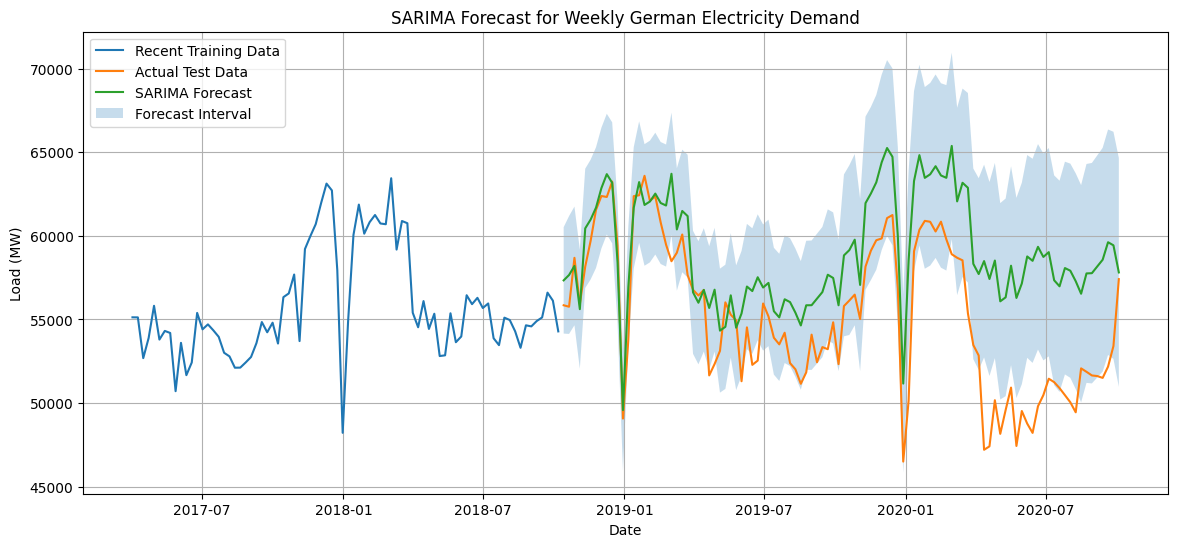

In [ ]:
# Plot final SARIMA forecast

plt.figure(figsize=(14, 6))

plt.plot(
    load_train.index[-80:],
    load_train.iloc[-80:],
    label="Recent Training Data"
)

plt.plot(
    load_test.index,
    load_test,
    label="Actual Test Data"
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA Forecast"
)

plt.fill_between(
    load_test.index,
    sarima_interval.iloc[:, 0],
    sarima_interval.iloc[:, 1],
    alpha=0.25,
    label="Forecast Interval"
)

plt.title("SARIMA Forecast for Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

3.2. Residual Diagnostics

In [ ]:
# Residual diagnostics

sarima_errors = sarima_fit.resid.dropna()

residual_summary = pd.DataFrame({
    "Metric": [
        "Mean residual",
        "Residual standard deviation",
        "Minimum residual",
        "Maximum residual"
    ],
    "Value": [
        sarima_errors.mean(),
        sarima_errors.std(),
        sarima_errors.min(),
        sarima_errors.max()
    ]
})

residual_summary

,Metric,Value
0,Mean residual,544.526588
1,Residual standard deviation,5504.931749
2,Minimum residual,-23988.584658
3,Maximum residual,47233.739583


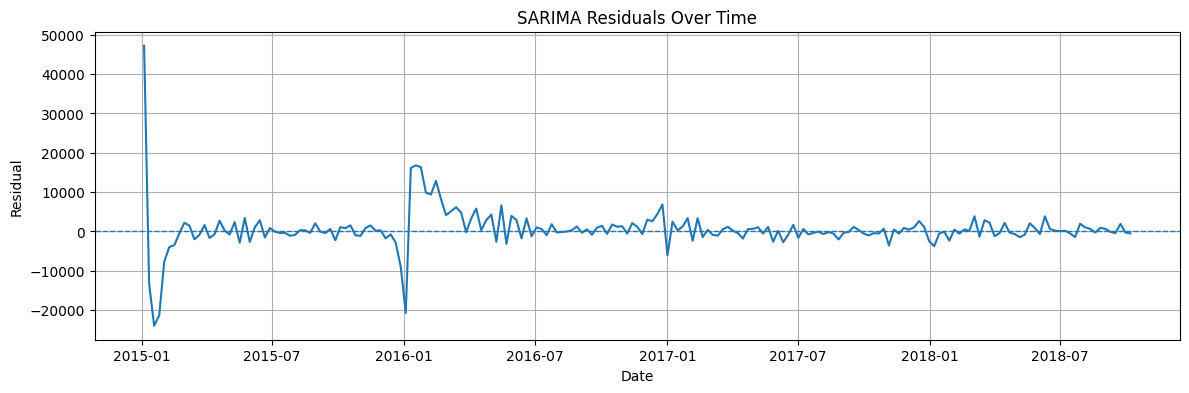

In [ ]:
# Residual plot

plt.figure(figsize=(14, 4))

plt.plot(
    sarima_errors.index,
    sarima_errors
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("SARIMA Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

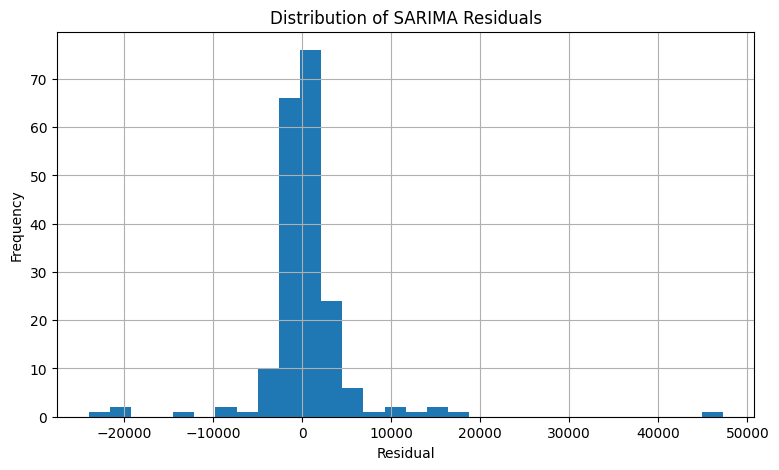

In [ ]:
# Residual distribution

plt.figure(figsize=(9, 5))

plt.hist(
    sarima_errors,
    bins=30
)

plt.title("Distribution of SARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<Figure size 1200x400 with 0 Axes>

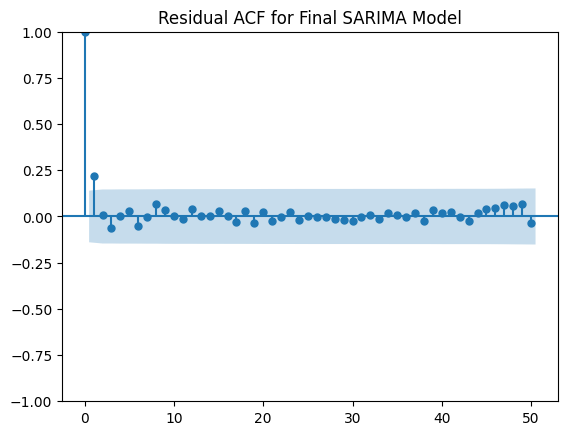

In [ ]:
# Residual autocorrelation

plt.figure(figsize=(12, 4))

plot_acf(
    sarima_errors,
    lags=50
)

plt.title("Residual ACF for Final SARIMA Model")
plt.show()

In [ ]:
sarima_result = pd.DataFrame({
    "Model": ["SARIMA"],
    "RMSE": [sarima_rmse],
    "MAE": [sarima_mae],
    "MAPE": [sarima_mape]
})

sarima_result

,Model,RMSE,MAE,MAPE
0,SARIMA,4765.231187,3883.622832,7.365725


###Part 4: SARIMAX With Temperature And Holiday Covariants

In [ ]:
#SARIMAX with temperature and holiday information

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# Installing holiday calendar package

!pip -q install holidays

import holidays

In [ ]:
# Berlin weather data from Open-Meteo archive API

weather_link = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-09-30"
    "&daily=temperature_2m_mean"
    "&timezone=UTC"
)

weather_response = requests.get(weather_link)
weather_json = weather_response.json()

weather_json.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

In [ ]:
# Convert weather response into a clean dataframe

berlin_weather = pd.DataFrame({
    "date": weather_json["daily"]["time"],
    "temperature": weather_json["daily"]["temperature_2m_mean"]
})

berlin_weather["date"] = pd.to_datetime(berlin_weather["date"])
berlin_weather = berlin_weather.set_index("date")

# Make the weather index timezone-aware like the electricity load data
berlin_weather.index = berlin_weather.index.tz_localize("UTC")

berlin_weather.head()

,temperature
date,
2015-01-01 00:00:00+00:00,2.6
2015-01-02 00:00:00+00:00,4.9
2015-01-03 00:00:00+00:00,3.8
2015-01-04 00:00:00+00:00,2.8
2015-01-05 00:00:00+00:00,2.9


In [ ]:
# Weekly average temperature to match weekly electricity demand

weekly_temperature = berlin_weather["temperature"].resample("W").mean()

print("Weekly temperature rows:", len(weekly_temperature))
weekly_temperature.head()

Weekly temperature rows: 301


,temperature
date,
2015-01-04 00:00:00+00:00,3.525000
2015-01-11 00:00:00+00:00,3.914286
2015-01-18 00:00:00+00:00,4.842857
2015-01-25 00:00:00+00:00,0.057143
2015-02-01 00:00:00+00:00,1.400000


In [ ]:
# German public holidays from 2015 to 2020

germany_holiday_calendar = holidays.Germany(
    years=range(2015, 2021)
)

print("Number of holiday records:", len(germany_holiday_calendar))

Number of holiday records: 55


In [ ]:
# Daily holiday flag
# 1 means the date is a public holiday, 0 means normal day

holiday_flag_daily = pd.Series(
    [
        1 if day.date() in germany_holiday_calendar else 0
        for day in daily_load.index
    ],
    index=daily_load.index,
    name="holiday"
)

holiday_flag_daily.head()

,holiday
timestamp,
2015-01-01 00:00:00+00:00,1
2015-01-02 00:00:00+00:00,0
2015-01-03 00:00:00+00:00,0
2015-01-04 00:00:00+00:00,0
2015-01-05 00:00:00+00:00,0


In [ ]:
# Weekly holiday count
# Some weeks may contain more than one public holiday

weekly_holiday_count = holiday_flag_daily.resample("W").sum()

weekly_holiday_count.head()

,holiday
timestamp,
2015-01-04 00:00:00+00:00,1
2015-01-11 00:00:00+00:00,0
2015-01-18 00:00:00+00:00,0
2015-01-25 00:00:00+00:00,0
2015-02-01 00:00:00+00:00,0


In [ ]:
# Combine weekly load, temperature, and holidays

weather_model_data = pd.DataFrame({
    "load": weekly_series,
    "temperature": weekly_temperature,
    "holiday_count": weekly_holiday_count
})

# I am Adding one-week temperature lag, bcoz this uses previous information and is useful for checking delayed weather effects

weather_model_data["temperature_lag1"] = weather_model_data["temperature"].shift(1)

weather_model_data = weather_model_data.dropna()

print(weather_model_data.head())
print(weather_model_data.tail())
print("Shape:", weather_model_data.shape)

                                   load  temperature  holiday_count  \
2015-01-11 00:00:00+00:00  56191.101190     3.914286              0   
2015-01-18 00:00:00+00:00  57672.678571     4.842857              0   
2015-01-25 00:00:00+00:00  58613.303571     0.057143              0   
2015-02-01 00:00:00+00:00  58734.029762     1.400000              0   
2015-02-08 00:00:00+00:00  59323.898810    -1.228571              0   

                           temperature_lag1  
2015-01-11 00:00:00+00:00          3.525000  
2015-01-18 00:00:00+00:00          3.914286  
2015-01-25 00:00:00+00:00          4.842857  
2015-02-01 00:00:00+00:00          0.057143  
2015-02-08 00:00:00+00:00          1.400000  
                                   load  temperature  holiday_count  \
2020-09-06 00:00:00+00:00  51617.744048    15.942857              0   
2020-09-13 00:00:00+00:00  51507.630952    16.485714              0   
2020-09-20 00:00:00+00:00  52181.327381    17.214286              0   
2020-09-27 00

In [ ]:
# Correlation check before modelling

covariate_correlation = weather_model_data[
    [
        "load",
        "temperature",
        "temperature_lag1",
        "holiday_count"
    ]
].corr()

covariate_correlation

,load,temperature,temperature_lag1,holiday_count
load,1.000000,-0.651146,-0.626664,-0.456240
temperature,-0.651146,1.000000,0.915936,-0.079514
temperature_lag1,-0.626664,0.915936,1.000000,-0.098504
holiday_count,-0.456240,-0.079514,-0.098504,1.000000


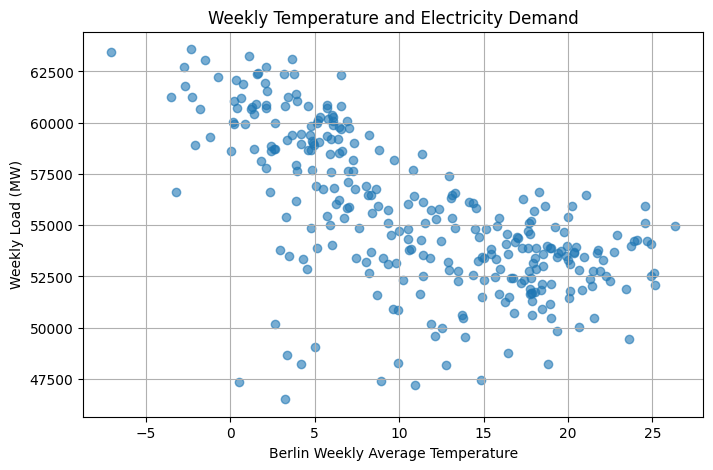

In [ ]:
# Visual check: temperature and load relationship

plt.figure(figsize=(8, 5))

plt.scatter(
    weather_model_data["temperature"],
    weather_model_data["load"],
    alpha=0.6
)

plt.title("Weekly Temperature and Electricity Demand")
plt.xlabel("Berlin Weekly Average Temperature")
plt.ylabel("Weekly Load (MW)")
plt.grid(True)
plt.show()

In [ ]:
# Visual check: average load in weeks with and without holidays

holiday_group_check = (
    weather_model_data
    .assign(has_holiday=lambda x: np.where(x["holiday_count"] > 0, "Holiday week", "Normal week"))
    .groupby("has_holiday")["load"]
    .mean()
    .reset_index()
)

holiday_group_check

,has_holiday,load
0,Holiday week,51673.901656
1,Normal week,56206.914479


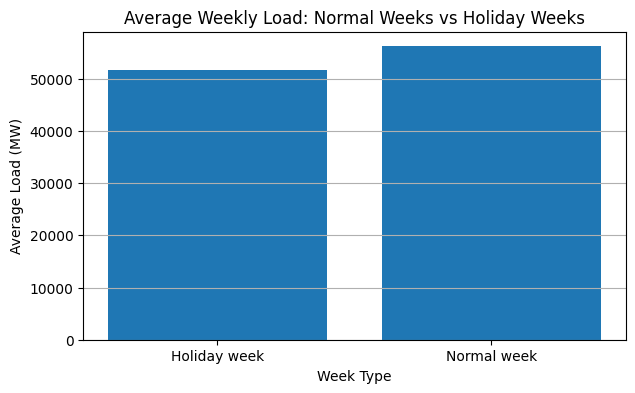

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    holiday_group_check["has_holiday"],
    holiday_group_check["load"]
)

plt.title("Average Weekly Load: Normal Weeks vs Holiday Weeks")
plt.xlabel("Week Type")
plt.ylabel("Average Load (MW)")
plt.grid(axis="y")
plt.show()

In [ ]:
# Same 104-week test horizon

weather_train = weather_model_data.iloc[:-test_weeks]
weather_test = weather_model_data.iloc[-test_weeks:]

target_train = weather_train["load"]
target_test = weather_test["load"]

print("Train size:", len(target_train))
print("Test size:", len(target_test))

Train size: 196
Test size: 104


In [ ]:
# Small function to fit and evaluate SARIMAX models

def run_sarimax_experiment(model_name, train_features, test_features):

    model = SARIMAX(
        target_train,
        exog=train_features,
        order=final_sarima_order,
        seasonal_order=seasonal_part,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)

    forecast_object = fitted_model.get_forecast(
        steps=len(target_test),
        exog=test_features
    )

    forecast_values = forecast_object.predicted_mean
    forecast_values.index = target_test.index

    confidence_interval = forecast_object.conf_int()
    confidence_interval.index = target_test.index

    rmse, mae, mape = forecast_error(
        target_test,
        forecast_values
    )

    result_row = {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

    return fitted_model, forecast_values, confidence_interval, result_row

In [ ]:
# Temperature-only SARIMAX

temperature_features_train = weather_train[
    [
        "temperature",
        "temperature_lag1"
    ]
]

temperature_features_test = weather_test[
    [
        "temperature",
        "temperature_lag1"
    ]
]

temp_fit, temp_forecast, temp_interval, temp_result = run_sarimax_experiment(
    "SARIMAX Temperature",
    temperature_features_train,
    temperature_features_test
)

temp_result

{'Model': 'SARIMAX Temperature',
 'RMSE': np.float64(6094.947109131409),
 'MAE': 5052.178056689123,
 'MAPE': np.float64(9.572743111648215)}

In [ ]:
# Temperature coefficients

temp_fit.params[
    temp_fit.params.index.str.contains("temperature")
]

,0
temperature,-113.257660
temperature_lag1,-43.580543


In [ ]:
# Temperature and holiday SARIMAX

holiday_features_train = weather_train[
    [
        "temperature",
        "temperature_lag1",
        "holiday_count"
    ]
]

holiday_features_test = weather_test[
    [
        "temperature",
        "temperature_lag1",
        "holiday_count"
    ]
]

holiday_fit, holiday_forecast, holiday_interval, holiday_result = run_sarimax_experiment(
    "SARIMAX Temperature + Holidays",
    holiday_features_train,
    holiday_features_test
)

holiday_result

{'Model': 'SARIMAX Temperature + Holidays',
 'RMSE': np.float64(5633.878793383652),
 'MAE': 4712.4653723850015,
 'MAPE': np.float64(8.917168252098431)}

In [ ]:
# Temperature and holiday coefficients

holiday_fit.params[
    holiday_fit.params.index.str.contains("temperature|holiday")
]

,0
temperature,-129.005315
temperature_lag1,-48.742282
holiday_count,-1903.230199


In [ ]:
sarimax_result_table = pd.DataFrame([
    {
        "Model": "SARIMA",
        "RMSE": sarima_rmse,
        "MAE": sarima_mae,
        "MAPE": sarima_mape
    },
    temp_result,
    holiday_result
])

sarimax_result_table.sort_values("RMSE")

,Model,RMSE,MAE,MAPE
0,SARIMA,4765.231187,3883.622832,7.365725
2,SARIMAX Temperature + Holidays,5633.878793,4712.465372,8.917168
1,SARIMAX Temperature,6094.947109,5052.178057,9.572743


In [ ]:
# Choose the better SARIMAX covariate forecast based on RMSE

if holiday_result["RMSE"] <= temp_result["RMSE"]:
    chosen_sarimax_name = "SARIMAX Temperature + Holidays"
    chosen_sarimax_forecast = holiday_forecast
    chosen_sarimax_interval = holiday_interval
    chosen_sarimax_fit = holiday_fit
else:
    chosen_sarimax_name = "SARIMAX Temperature"
    chosen_sarimax_forecast = temp_forecast
    chosen_sarimax_interval = temp_interval
    chosen_sarimax_fit = temp_fit

print("Best SARIMAX covariate model:", chosen_sarimax_name)

Best SARIMAX covariate model: SARIMAX Temperature + Holidays


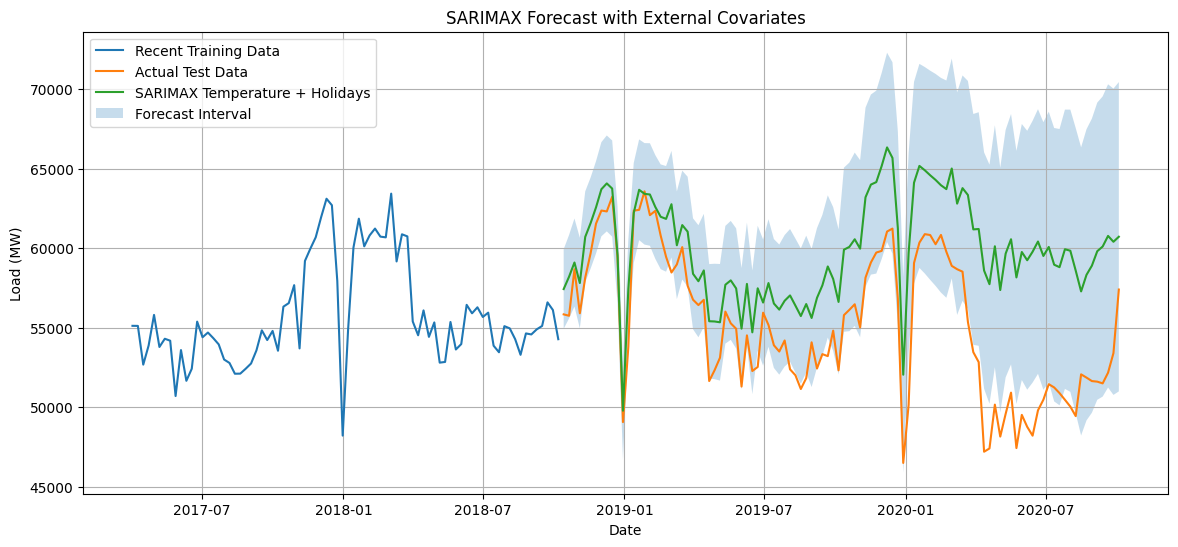

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    target_train.index[-80:],
    target_train.iloc[-80:],
    label="Recent Training Data"
)

plt.plot(
    target_test.index,
    target_test,
    label="Actual Test Data"
)

plt.plot(
    chosen_sarimax_forecast.index,
    chosen_sarimax_forecast,
    label=chosen_sarimax_name
)

plt.fill_between(
    target_test.index,
    chosen_sarimax_interval.iloc[:, 0],
    chosen_sarimax_interval.iloc[:, 1],
    alpha=0.25,
    label="Forecast Interval"
)

plt.title("SARIMAX Forecast with External Covariates")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Store the best SARIMAX model result

best_sarimax_row = (
    sarimax_result_table
    .query("Model != 'SARIMA'")
    .sort_values("RMSE")
    .iloc[0]
)

sarimax_result = pd.DataFrame({
    "Model": [best_sarimax_row["Model"]],
    "RMSE": [best_sarimax_row["RMSE"]],
    "MAE": [best_sarimax_row["MAE"]],
    "MAPE": [best_sarimax_row["MAPE"]]
})

sarimax_result

,Model,RMSE,MAE,MAPE
0,SARIMAX Temperature + Holidays,5633.878793,4712.465372,8.917168


In [ ]:
# Keep these variables for later final comparison

sarimax_rmse = sarimax_result["RMSE"].iloc[0]
sarimax_mae = sarimax_result["MAE"].iloc[0]
sarimax_mape = sarimax_result["MAPE"].iloc[0]

print("Stored SARIMAX result")
print("RMSE:", sarimax_rmse)
print("MAE:", sarimax_mae)
print("MAPE:", sarimax_mape)

Stored SARIMAX result
RMSE: 5633.878793383652
MAE: 4712.4653723850015
MAPE: 8.917168252098431


###Part 5: Feature Based Machine Learning Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
machine_data = weather_model_data.copy()

machine_data.head()

,load,temperature,holiday_count,temperature_lag1
2015-01-11 00:00:00+00:00,56191.101190,3.914286,0,3.525000
2015-01-18 00:00:00+00:00,57672.678571,4.842857,0,3.914286
2015-01-25 00:00:00+00:00,58613.303571,0.057143,0,4.842857
2015-02-01 00:00:00+00:00,58734.029762,1.400000,0,0.057143
2015-02-08 00:00:00+00:00,59323.898810,-1.228571,0,1.400000


In [ ]:
# Lag features from previous demand values

for lag in [1, 2, 4, 13, 26, 52]:
    machine_data[f"load_lag_{lag}"] = machine_data["load"].shift(lag)

In [ ]:
# Rolling features
machine_data["recent_average_4"] = (
    machine_data["load"]
    .shift(1)
    .rolling(4)
    .mean()
)

machine_data["recent_median_8"] = (
    machine_data["load"]
    .shift(1)
    .rolling(8)
    .median()
)

machine_data["recent_volatility_12"] = (
    machine_data["load"]
    .shift(1)
    .rolling(12)
    .std()
)

In [ ]:
# Weather movement feature

machine_data["temperature_change"] = (
    machine_data["temperature"] - machine_data["temperature_lag1"]
)

In [ ]:
# Calendar features

machine_data["week_number"] = machine_data.index.isocalendar().week.astype(int)
machine_data["month_number"] = machine_data.index.month

machine_data["week_sin"] = np.sin(
    2 * np.pi * machine_data["week_number"] / 52
)

machine_data["week_cos"] = np.cos(
    2 * np.pi * machine_data["week_number"] / 52
)

machine_data["month_sin"] = np.sin(
    2 * np.pi * machine_data["month_number"] / 12
)

machine_data["month_cos"] = np.cos(
    2 * np.pi * machine_data["month_number"] / 12
)

In [ ]:
# Remove rows where lag or rolling features are missing

machine_data = machine_data.dropna()

print("Feature table shape:", machine_data.shape)
machine_data.head()

Feature table shape: (248, 20)


,load,temperature,holiday_count,temperature_lag1,load_lag_1,load_lag_2,load_lag_4,load_lag_13,load_lag_26,load_lag_52,recent_average_4,recent_median_8,recent_volatility_12,temperature_change,week_number,month_number,week_sin,week_cos,month_sin,month_cos
2016-01-10 00:00:00+00:00,56615.142857,-3.228571,0,0.514286,47364.035714,48253.363095,59907.333333,54714.547619,53877.928571,56191.101190,53288.147321,58936.693452,4354.952831,-3.742857,1,1,0.120537,0.992709,0.500000,0.866025
2016-01-17 00:00:00+00:00,59913.910714,0.228571,0,-3.228571,56615.142857,47364.035714,57627.857143,56243.970238,53722.517857,57672.678571,52465.099702,58505.014881,4355.597091,3.457143,2,1,0.239316,0.970942,0.500000,0.866025
2016-01-24 00:00:00+00:00,61267.529762,-3.542857,0,0.228571,59913.910714,56615.142857,48253.363095,55763.964286,53660.047619,58613.303571,53036.613095,58767.595238,4467.130964,-3.771429,3,1,0.354605,0.935016,0.500000,0.866025
2016-01-31 00:00:00+00:00,59185.089286,6.400000,0,-3.542857,61267.529762,59913.910714,47364.035714,55601.589286,52311.184524,58734.029762,56290.154762,58767.595238,4635.840939,9.942857,4,1,0.464723,0.885456,0.500000,0.866025
2016-02-07 00:00:00+00:00,59329.809524,5.742857,0,6.400000,59185.089286,61267.529762,56615.142857,56496.375000,52515.363095,59323.898810,59245.418155,58406.473214,4664.689525,-0.657143,5,2,0.568065,0.822984,0.866025,0.500000


In [ ]:
lag_features = [
    "load_lag_1",
    "load_lag_2",
    "load_lag_4",
    "load_lag_13",
    "load_lag_26",
    "load_lag_52"
]

rolling_features = [
    "recent_average_4",
    "recent_median_8",
    "recent_volatility_12"
]

weather_features = [
    "temperature",
    "temperature_lag1",
    "temperature_change"
]

calendar_features = [
    "holiday_count",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos"
]

model_features = (
    lag_features
    + rolling_features
    + weather_features
    + calendar_features
)

target_column = "load"

print("Number of features:", len(model_features))

Number of features: 17


In [ ]:
X = machine_data[model_features]
y = machine_data[target_column]

X.head()

,load_lag_1,load_lag_2,load_lag_4,load_lag_13,load_lag_26,load_lag_52,recent_average_4,recent_median_8,recent_volatility_12,temperature,temperature_lag1,temperature_change,holiday_count,week_sin,week_cos,month_sin,month_cos
2016-01-10 00:00:00+00:00,47364.035714,48253.363095,59907.333333,54714.547619,53877.928571,56191.101190,53288.147321,58936.693452,4354.952831,-3.228571,0.514286,-3.742857,0,0.120537,0.992709,0.500000,0.866025
2016-01-17 00:00:00+00:00,56615.142857,47364.035714,57627.857143,56243.970238,53722.517857,57672.678571,52465.099702,58505.014881,4355.597091,0.228571,-3.228571,3.457143,0,0.239316,0.970942,0.500000,0.866025
2016-01-24 00:00:00+00:00,59913.910714,56615.142857,48253.363095,55763.964286,53660.047619,58613.303571,53036.613095,58767.595238,4467.130964,-3.542857,0.228571,-3.771429,0,0.354605,0.935016,0.500000,0.866025
2016-01-31 00:00:00+00:00,61267.529762,59913.910714,47364.035714,55601.589286,52311.184524,58734.029762,56290.154762,58767.595238,4635.840939,6.400000,-3.542857,9.942857,0,0.464723,0.885456,0.500000,0.866025
2016-02-07 00:00:00+00:00,59185.089286,61267.529762,56615.142857,56496.375000,52515.363095,59323.898810,59245.418155,58406.473214,4664.689525,5.742857,6.400000,-0.657143,0,0.568065,0.822984,0.866025,0.500000


In [ ]:
# Same 104 week test

split_point = len(machine_data) - test_weeks

X_train_ml = X.iloc[:split_point]
X_test_ml = X.iloc[split_point:]

y_train_ml = y.iloc[:split_point]
y_test_ml = y.iloc[split_point:]

print("Training shape:", X_train_ml.shape)
print("Testing shape:", X_test_ml.shape)

Training shape: (144, 17)
Testing shape: (104, 17)


In [ ]:
forest_settings = [
    {
        "name": "Small Forest",
        "n_estimators": 200,
        "max_depth": 6,
        "min_samples_leaf": 3
    },
    {
        "name": "Medium Forest",
        "n_estimators": 400,
        "max_depth": 10,
        "min_samples_leaf": 2
    },
    {
        "name": "Deep Forest",
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1
    }
]

In [ ]:
forest_results = []
forest_models = {}

for setting in forest_settings:

    rf = RandomForestRegressor(
        n_estimators=setting["n_estimators"],
        max_depth=setting["max_depth"],
        min_samples_leaf=setting["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train_ml,
        y_train_ml
    )

    prediction = rf.predict(
        X_test_ml
    )

    rmse, mae, mape = forecast_error(
        y_test_ml,
        prediction
    )

    forest_results.append({
        "Model": setting["name"],
        "Trees": setting["n_estimators"],
        "Max Depth": setting["max_depth"],
        "Min Leaf": setting["min_samples_leaf"],
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

    forest_models[setting["name"]] = rf

forest_comparison = (
    pd.DataFrame(forest_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

forest_comparison

,Model,Trees,Max Depth,Min Leaf,RMSE,MAE,MAPE
0,Medium Forest,400,10.0,2,2505.597735,1826.493059,3.507423
1,Deep Forest,500,NaN,1,2507.007503,1804.474028,3.468153
2,Small Forest,200,6.0,3,2562.682897,1865.534898,3.583569


In [ ]:
best_forest_name = forest_comparison.loc[0, "Model"]

final_forest = forest_models[best_forest_name]

print("Selected model:", best_forest_name)

Selected model: Medium Forest


In [ ]:
forest_prediction = final_forest.predict(
    X_test_ml
)

forest_forecast = pd.Series(
    forest_prediction,
    index=y_test_ml.index,
    name="Random Forest Forecast"
)

forest_rmse, forest_mae, forest_mape = forecast_error(
    y_test_ml,
    forest_forecast
)

print("Random Forest Results")
print("RMSE:", forest_rmse)
print("MAE:", forest_mae)
print("MAPE:", forest_mape)

Random Forest Results
RMSE: 2505.597735188155
MAE: 1826.4930588907334
MAPE: 3.5074227994709237


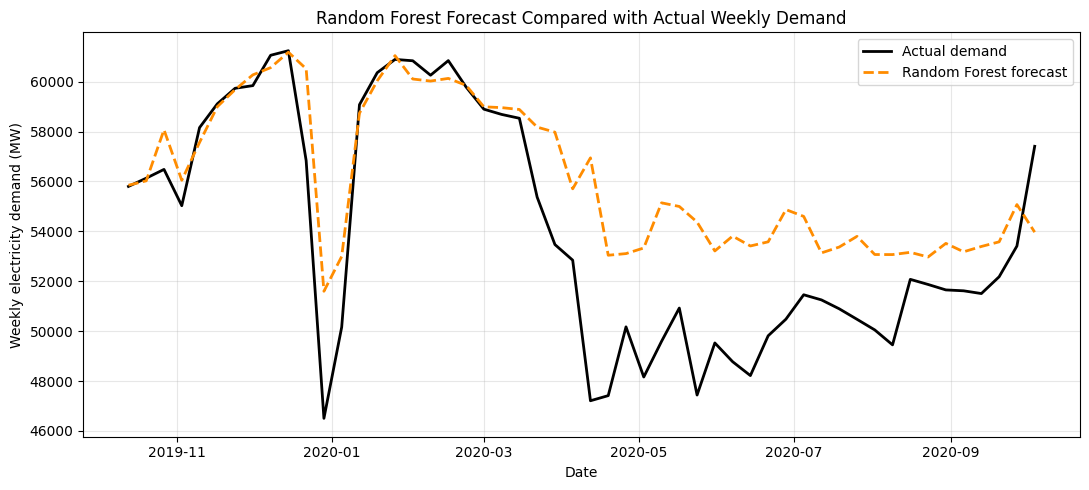

In [ ]:
rf_check = pd.DataFrame({
    "Actual demand": y_test_ml,
    "Random Forest forecast": forest_forecast
}).dropna()

rf_check = rf_check.tail(52)

plt.figure(figsize=(11, 5))

plt.plot(
    rf_check.index,
    rf_check["Actual demand"],
    color="black",
    linewidth=2,
    label="Actual demand"
)

plt.plot(
    rf_check.index,
    rf_check["Random Forest forecast"],
    color="darkorange",
    linewidth=2,
    linestyle="--",
    label="Random Forest forecast"
)

plt.title("Random Forest Forecast Compared with Actual Weekly Demand")
plt.xlabel("Date")
plt.ylabel("Weekly electricity demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
importance_table = pd.DataFrame({
    "Feature": model_features,
    "Importance": final_forest.feature_importances_
})

importance_table = (
    importance_table
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_table.head(12)

,Feature,Importance
0,load_lag_52,0.798730
1,load_lag_1,0.050005
2,temperature,0.029959
3,week_cos,0.019504
4,holiday_count,0.018167
5,load_lag_4,0.011587
6,load_lag_26,0.010657
7,temperature_lag1,0.010034
8,recent_average_4,0.009118
9,recent_median_8,0.008632


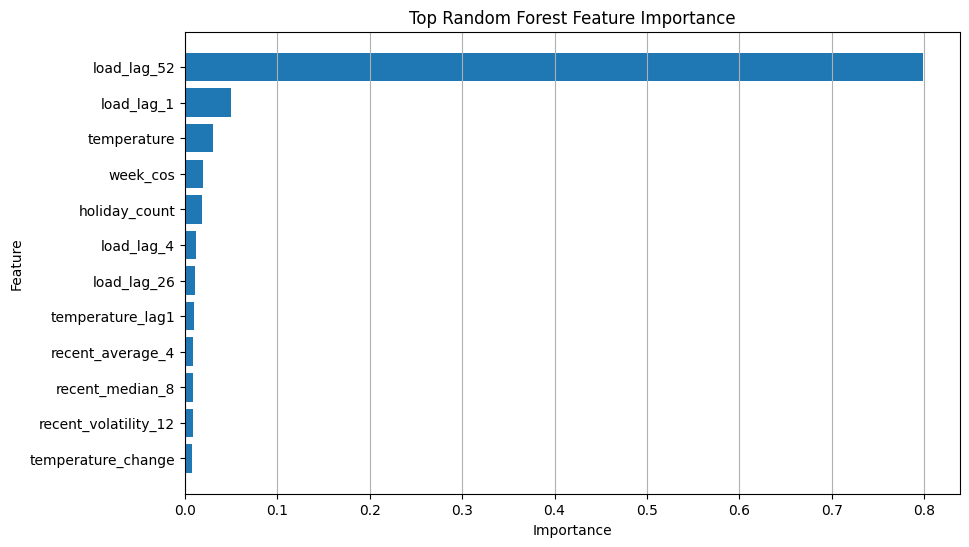

In [ ]:
top_features = importance_table.head(12)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [ ]:
def feature_group_name(feature):

    if feature in lag_features:
        return "Lag features"

    if feature in rolling_features:
        return "Rolling features"

    if feature in weather_features:
        return "Weather features"

    if feature in calendar_features:
        return "Calendar and holiday features"

    return "Other"

In [ ]:
importance_table["Feature Group"] = importance_table["Feature"].apply(
    feature_group_name
)

group_importance = (
    importance_table
    .groupby("Feature Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

group_importance

,Feature Group,Importance
0,Lag features,0.882902
1,Weather features,0.047506
2,Calendar and holiday features,0.043332
3,Rolling features,0.026261


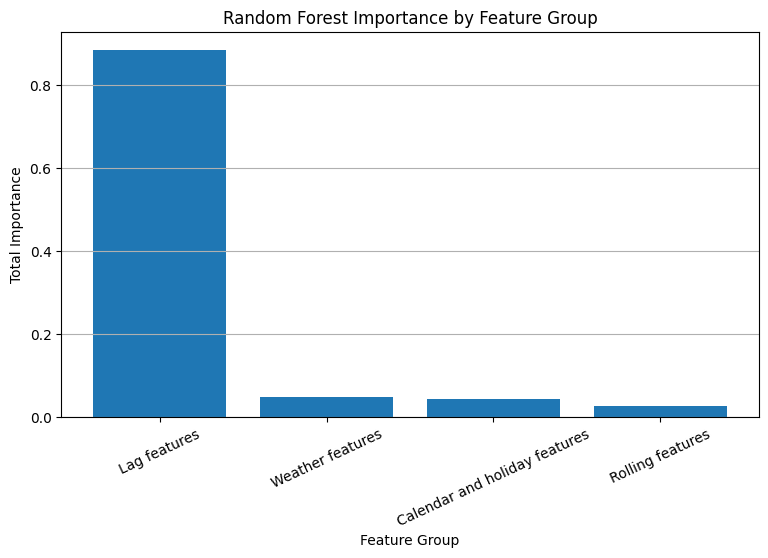

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    group_importance["Feature Group"],
    group_importance["Importance"]
)

plt.title("Random Forest Importance by Feature Group")
plt.xlabel("Feature Group")
plt.ylabel("Total Importance")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

In [ ]:
feature_model_result = pd.DataFrame({
    "Model": ["Random Forest"],
    "RMSE": [forest_rmse],
    "MAE": [forest_mae],
    "MAPE": [forest_mape]
})

feature_model_result

,Model,RMSE,MAE,MAPE
0,Random Forest,2505.597735,1826.493059,3.507423


In [ ]:
rf_rmse = forest_rmse
rf_mae = forest_mae
rf_mape = forest_mape

print("Feature-based model result stored")

Feature-based model result stored


###Part 6: LSTM Model

In [ ]:
# Part 6 - LSTM model for hourly electricity demand
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

In [ ]:
# LSTM uses the original hourly load data

hourly_series = load_data[["load"]].copy()

print(hourly_series.head())
print(hourly_series.tail())
print("Hourly shape:", hourly_series.shape)

                              load
timestamp                         
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                              load
timestamp                         
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0
Hourly shape: (50400, 1)


In [ ]:
# Last two years of hourly data are used for testing

test_hours = 24 * 365 * 2

hourly_train = hourly_series.iloc[:-test_hours]
hourly_test = hourly_series.iloc[-test_hours:]

print("Training period:", hourly_train.index.min(), "to", hourly_train.index.max())
print("Testing period:", hourly_test.index.min(), "to", hourly_test.index.max())

print("Train shape:", hourly_train.shape)
print("Test shape:", hourly_test.shape)

Training period: 2015-01-01 00:00:00+00:00 to 2018-10-01 23:00:00+00:00
Testing period: 2018-10-02 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Train shape: (32880, 1)
Test shape: (17520, 1)


In [ ]:
# Fit scaler only on training data to avoid leakage

load_scaler = MinMaxScaler()

scaled_train = load_scaler.fit_transform(hourly_train)
scaled_test = load_scaler.transform(hourly_test)

print(scaled_train.shape)
print(scaled_test.shape)

(32880, 1)
(17520, 1)


In [ ]:
# Function for creating LSTM input windows

def create_windows(data_array, window_size):

    X_values = []
    y_values = []

    for i in range(window_size, len(data_array)):
        X_values.append(data_array[i-window_size:i])
        y_values.append(data_array[i, 0])

    return np.array(X_values), np.array(y_values)

In [ ]:
# Function to run one LSTM setting

def run_lstm_model(model_name, window_size, units_first, units_second=None, dropout_rate=0.2, epochs_count=5):

    K.clear_session()

    X_train_temp, y_train_temp = create_windows(
        scaled_train,
        window_size
    )

    test_input = np.concatenate(
        [
            scaled_train[-window_size:],
            scaled_test
        ]
    )

    X_test_temp, y_test_temp = create_windows(
        test_input,
        window_size
    )

    model = Sequential()

    if units_second is None:
        model.add(
            LSTM(
                units_first,
                input_shape=(X_train_temp.shape[1], X_train_temp.shape[2])
            )
        )

        model.add(
            Dropout(dropout_rate)
        )

    else:
        model.add(
            LSTM(
                units_first,
                return_sequences=True,
                input_shape=(X_train_temp.shape[1], X_train_temp.shape[2])
            )
        )

        model.add(
            Dropout(dropout_rate)
        )

        model.add(
            LSTM(units_second)
        )

        model.add(
            Dropout(dropout_rate)
        )

    model.add(
        Dense(1)
    )

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    stopping_rule = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_temp,
        y_train_temp,
        epochs=epochs_count,
        batch_size=128,
        validation_split=0.1,
        callbacks=[stopping_rule],
        verbose=1
    )

    prediction_scaled = model.predict(
        X_test_temp
    )

    prediction = load_scaler.inverse_transform(
        prediction_scaled
    ).flatten()

    actual = load_scaler.inverse_transform(
        y_test_temp.reshape(-1, 1)
    ).flatten()

    rmse = np.sqrt(
        mean_squared_error(actual, prediction)
    )

    mae = mean_absolute_error(
        actual,
        prediction
    )

    mape = np.mean(
        np.abs((actual - prediction) / actual)
    ) * 100

    result = {
        "Model": model_name,
        "Lookback Hours": window_size,
        "Layer Design": str(units_first) if units_second is None else str(units_first) + " + " + str(units_second),
        "Dropout": dropout_rate,
        "Epochs": epochs_count,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

    return model, history, prediction, actual, result

In [ ]:
lstm_settings = [
    {
        "name": "Short Memory LSTM",
        "window": 48,
        "units_1": 32,
        "units_2": None,
        "dropout": 0.20,
        "epochs": 4
    },
    {
        "name": "Weekly Memory LSTM",
        "window": 168,
        "units_1": 50,
        "units_2": 50,
        "dropout": 0.20,
        "epochs": 8
    },
    {
        "name": "Two Week Memory LSTM",
        "window": 336,
        "units_1": 64,
        "units_2": 32,
        "dropout": 0.25,
        "epochs": 4
    }
]

In [ ]:
lstm_results = []
lstm_models = {}
lstm_histories = {}
lstm_predictions = {}
lstm_actuals = {}

for setting in lstm_settings:

    model, history, prediction, actual, result = run_lstm_model(
        model_name=setting["name"],
        window_size=setting["window"],
        units_first=setting["units_1"],
        units_second=setting["units_2"],
        dropout_rate=setting["dropout"],
        epochs_count=setting["epochs"]
    )

    lstm_results.append(result)
    lstm_models[setting["name"]] = model
    lstm_histories[setting["name"]] = history
    lstm_predictions[setting["name"]] = prediction
    lstm_actuals[setting["name"]] = actual

In [ ]:
# LSTM tuning result table

lstm_tuning_table = (
    pd.DataFrame(lstm_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

lstm_tuning_table

,Model,Lookback Hours,Layer Design,Dropout,Epochs,RMSE,MAE,MAPE
0,Weekly Memory LSTM,168,50 + 50,0.20,8,1690.023376,1282.099522,2.404779
1,Short Memory LSTM,48,32,0.20,4,2231.346566,1648.839167,3.091199
2,Two Week Memory LSTM,336,64 + 32,0.25,4,2247.753802,1655.066063,3.168818


In [ ]:
# Select the best LSTM based on RMSE

best_lstm_name = lstm_tuning_table.loc[0, "Model"]

print("Best LSTM setting:", best_lstm_name)

Best LSTM setting: Weekly Memory LSTM


In [ ]:
best_lstm_prediction = lstm_predictions[best_lstm_name]
best_lstm_actual = lstm_actuals[best_lstm_name]
best_lstm_history = lstm_histories[best_lstm_name]

lstm_rmse = lstm_tuning_table.loc[0, "RMSE"]
lstm_mae = lstm_tuning_table.loc[0, "MAE"]
lstm_mape = lstm_tuning_table.loc[0, "MAPE"]

print("Final LSTM Results")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

Final LSTM Results
RMSE: 1690.0233764083257
MAE: 1282.099521528967
MAPE: 2.4047789484051423


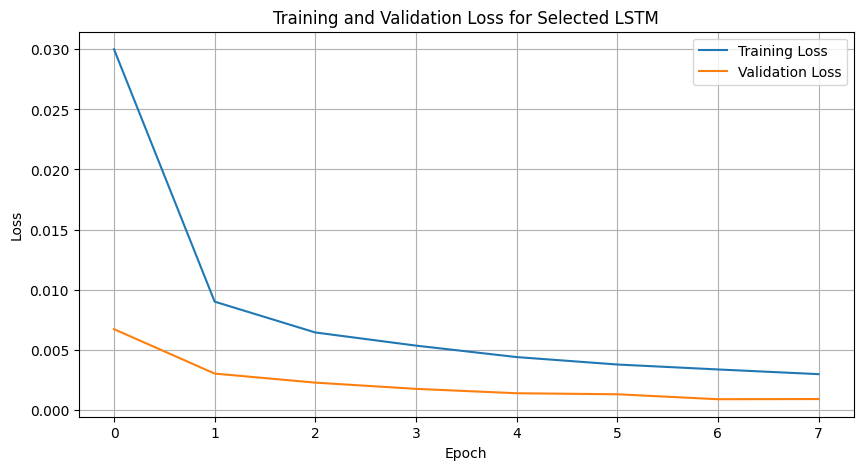

In [ ]:
# Training and validation loss for the selected LSTM model

plt.figure(figsize=(10, 5))

plt.plot(
    best_lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss for Selected LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create series for plotting

lstm_test_index = hourly_test.index

lstm_forecast_series = pd.Series(
    best_lstm_prediction,
    index=lstm_test_index,
    name="LSTM Forecast"
)

lstm_actual_series = pd.Series(
    best_lstm_actual,
    index=lstm_test_index,
    name="Actual Load"
)

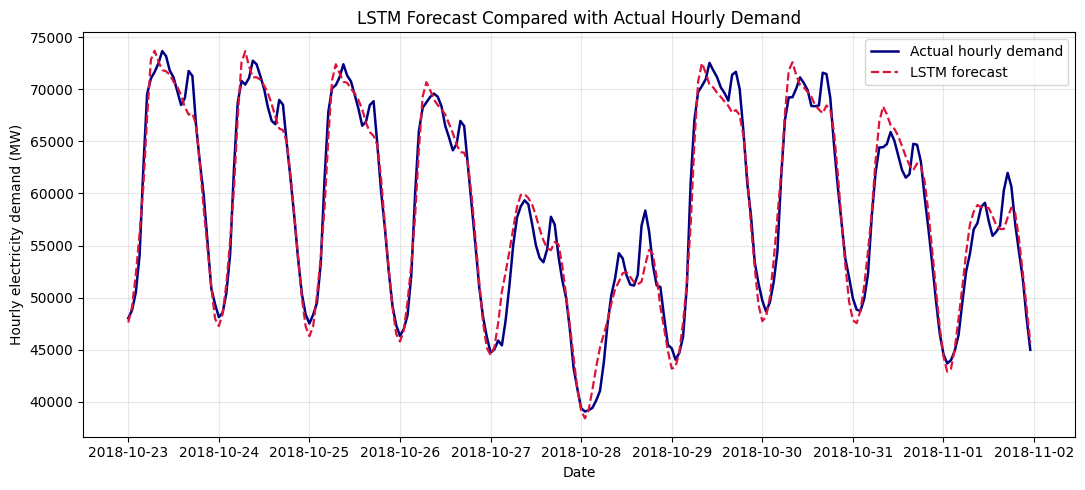

In [ ]:
sample_start = 24 * 21      # starting after three weeks of the test period
sample_length = 24 * 10     # show ten days

lstm_sample = pd.DataFrame({
    "Actual demand": lstm_actual_series,
    "LSTM forecast": lstm_forecast_series
}).dropna()

lstm_sample = lstm_sample.iloc[
    sample_start:sample_start + sample_length
]

plt.figure(figsize=(11, 5))

plt.plot(
    lstm_sample.index,
    lstm_sample["Actual demand"],
    color="navy",
    linewidth=1.8,
    label="Actual hourly demand"
)

plt.plot(
    lstm_sample.index,
    lstm_sample["LSTM forecast"],
    color="crimson",
    linewidth=1.6,
    linestyle="--",
    label="LSTM forecast"
)

plt.title("LSTM Forecast Compared with Actual Hourly Demand")
plt.xlabel("Date")
plt.ylabel("Hourly electricity demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Aggregating hourly LSTM output to weekly averages, this makes the LSTM easier to compare with weekly models

weekly_lstm_actual = lstm_actual_series.resample("W").mean()
weekly_lstm_forecast = lstm_forecast_series.resample("W").mean()

weekly_lstm_actual, weekly_lstm_forecast = weekly_lstm_actual.align(
    weekly_lstm_forecast,
    join="inner"
)

lstm_weekly_rmse, lstm_weekly_mae, lstm_weekly_mape = forecast_error(
    weekly_lstm_actual,
    weekly_lstm_forecast
)

print("Weekly Aggregated LSTM Results")
print("RMSE:", lstm_weekly_rmse)
print("MAE:", lstm_weekly_mae)
print("MAPE:", lstm_weekly_mape)

Weekly Aggregated LSTM Results
RMSE: 321.95558805019573
MAE: 253.23931228741492
MAPE: 0.48172147831833984


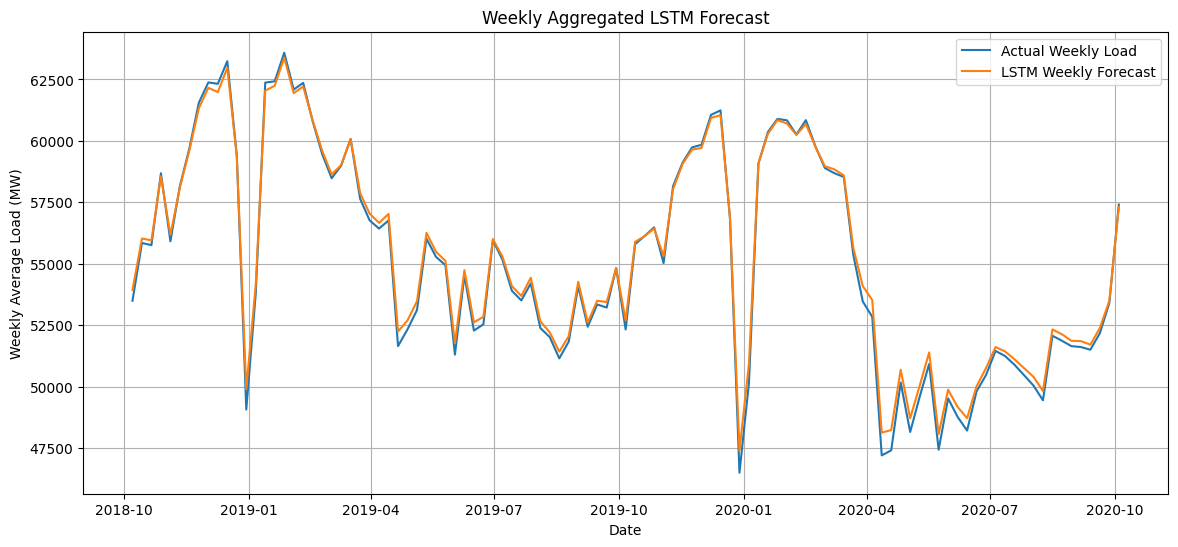

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_lstm_actual.index,
    weekly_lstm_actual,
    label="Actual Weekly Load"
)

plt.plot(
    weekly_lstm_forecast.index,
    weekly_lstm_forecast,
    label="LSTM Weekly Forecast"
)

plt.title("Weekly Aggregated LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Average Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Store hourly LSTM result for the final comparison

lstm_result = pd.DataFrame({
    "Model": ["LSTM"],
    "RMSE": [lstm_rmse],
    "MAE": [lstm_mae],
    "MAPE": [lstm_mape]
})

lstm_result

,Model,RMSE,MAE,MAPE
0,LSTM,1690.023376,1282.099522,2.404779


In [ ]:
print("LSTM result stored")
print("Note: the LSTM I made was evaluated on hourly data, while SARIMA, SARIMAX and Random Forest used weekly data.")

LSTM result stored
Note: the LSTM I made was evaluated on hourly data, while SARIMA, SARIMAX and Random Forest used weekly data.


In [ ]:
# Calculate Seasonal Naive forecast and metrics
# Seasonal Naive model assumes the forecast for the next season is the value from the current season of the previous year.
# For weekly data, the seasonality period is 52 weeks.
seasonal_naive_forecast = benchmark_forecasts["Seasonal Naive"]

seasonal_naive_row = benchmark_table[
    benchmark_table["Model"] == "Seasonal Naive"
].iloc[0]

seasonal_naive_rmse = seasonal_naive_row["RMSE"]
seasonal_naive_mae = seasonal_naive_row["MAE"]
seasonal_naive_mape = seasonal_naive_row["MAPE"]

print("Correct Seasonal Naive Results")
print("RMSE:", seasonal_naive_rmse)
print("MAE:", seasonal_naive_mae)
print("MAPE:", seasonal_naive_mape)


Correct Seasonal Naive Results
RMSE: 3006.7608119599954
MAE: 2318.5205853174602
MAPE: 4.408919739301198


In [ ]:
# Final model comparison table

final_model_table = pd.concat(
    [
        pd.DataFrame({
            "Model": ["Seasonal Naive"],
            "Frequency": ["Weekly"],
            "RMSE": [seasonal_naive_rmse],
            "MAE": [seasonal_naive_mae],
            "MAPE": [seasonal_naive_mape]
        }),
        sarima_result.assign(Frequency="Weekly"),
        sarimax_result.assign(Frequency="Weekly"),
        feature_model_result.assign(Frequency="Weekly"),
        lstm_result.assign(Frequency="Hourly")
    ],
    ignore_index=True
)

final_model_table = final_model_table[
    ["Model", "Frequency", "RMSE", "MAE", "MAPE"]
]

final_model_table.sort_values("RMSE")

,Model,Frequency,RMSE,MAE,MAPE
4,LSTM,Hourly,1690.023376,1282.099522,2.404779
3,Random Forest,Weekly,2505.597735,1826.493059,3.507423
0,Seasonal Naive,Weekly,3006.760812,2318.520585,4.408920
1,SARIMA,Weekly,4765.231187,3883.622832,7.365725
2,SARIMAX Temperature + Holidays,Weekly,5633.878793,4712.465372,8.917168


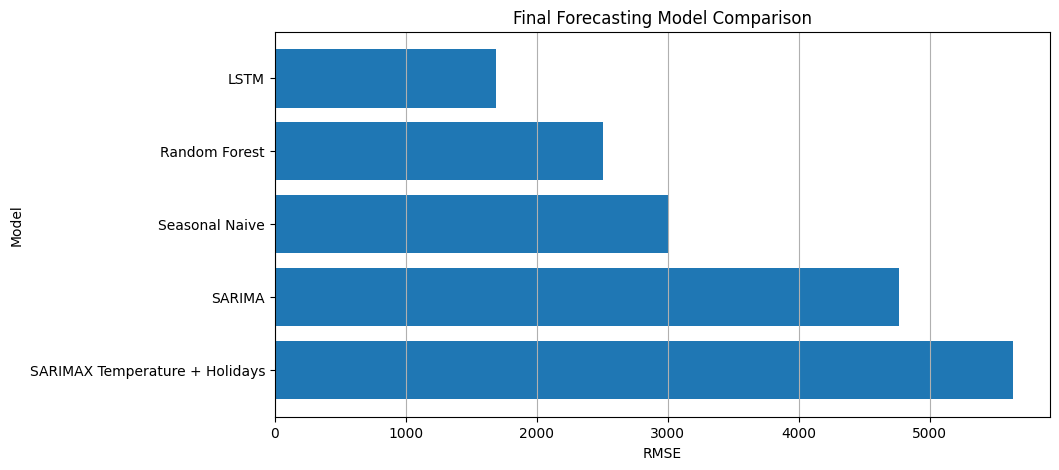

In [ ]:
# Final RMSE comparison plot

plot_table = final_model_table.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_table["Model"],
    plot_table["RMSE"]
)

plt.title("Final Forecasting Model Comparison")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

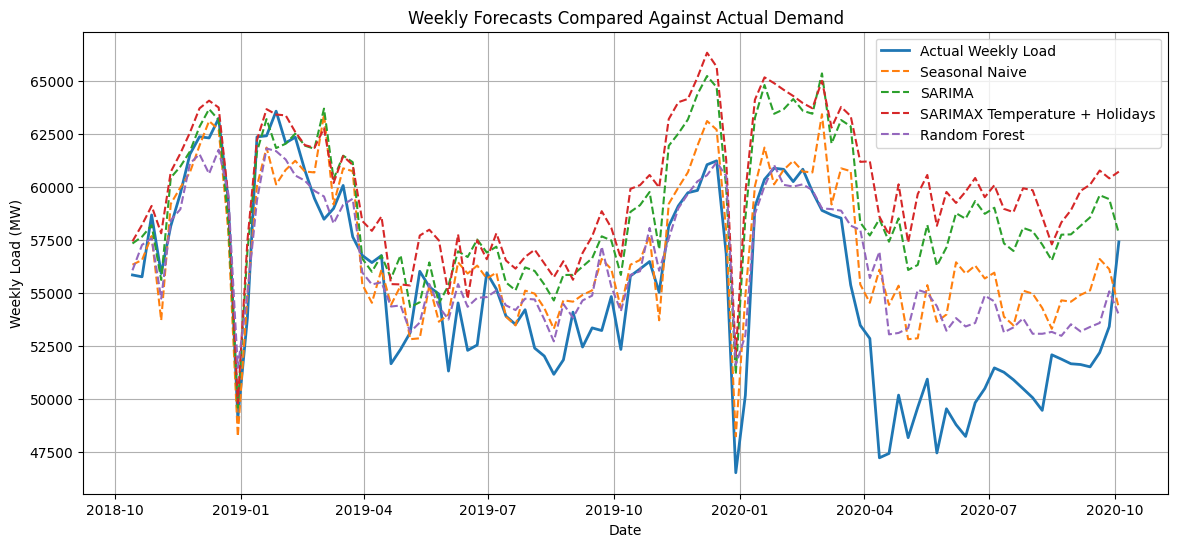

In [ ]:
# Weekly forecast comparison
# LSTM is not included here because it was trained and evaluated on hourly data

plt.figure(figsize=(14, 6))

plt.plot(
    load_test.index,
    load_test,
    label="Actual Weekly Load",
    linewidth=2
)

plt.plot(
    load_test.index,
    seasonal_naive_forecast,
    label="Seasonal Naive",
    linestyle="--"
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA",
    linestyle="--"
)

plt.plot(
    chosen_sarimax_forecast.index,
    chosen_sarimax_forecast,
    label=chosen_sarimax_name,
    linestyle="--"
)

plt.plot(
    forest_forecast.index,
    forest_forecast,
    label="Random Forest",
    linestyle="--"
)

plt.title("Weekly Forecasts Compared Against Actual Demand")
plt.xlabel("Date")
plt.ylabel("Weekly Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Best model based on RMSE

best_model_row = final_model_table.sort_values("RMSE").iloc[0]

print("Best model based on RMSE:")
print(best_model_row)